In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [ ]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [ ]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [ ]:
print(sentiment.shape)
print(trades.shape)

(2644, 4)
(211224, 16)


In [ ]:
sentiment.isna().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [ ]:
trades.isna().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
sentiment.duplicated().sum()

np.int64(0)

In [ ]:
trades.duplicated().sum()

np.int64(0)

In [ ]:
trades["Timestamp IST"].head()

,Timestamp IST
0,02-12-2024 22:50
1,02-12-2024 22:50
2,02-12-2024 22:50
3,02-12-2024 22:50
4,02-12-2024 22:50


In [ ]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.date

In [ ]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['Date'] = trades['Timestamp IST'].dt.date

In [ ]:
trades[['Timestamp IST', 'Date']].head()

,Timestamp IST,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [ ]:
sentiment[['date', 'Date']].head()

,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [ ]:
print(sentiment['Date'].min(), sentiment['Date'].max())
print(trades['Date'].min(), trades['Date'].max())

2018-02-01 2025-05-02
2023-05-01 2025-05-01


In [ ]:
merged = pd.merge(trades, sentiment, on='Date', how='inner')

In [ ]:
print(merged.shape)
print(merged[['Date','classification']].head())

(211218, 21)
         Date classification
0  2024-12-02  Extreme Greed
1  2024-12-02  Extreme Greed
2  2024-12-02  Extreme Greed
3  2024-12-02  Extreme Greed
4  2024-12-02  Extreme Greed


In [ ]:
daily_pnl_per_trader = merged.groupby(["Date","Account"])["Closed PnL"].sum()

In [ ]:
daily_pnl_per_trader=daily_pnl_per_trader.reset_index()

In [ ]:
daily_pnl_per_trader = daily_pnl_per_trader.rename(columns={"Closed PnL" :"daily_pnl"})

In [ ]:
daily_pnl_per_trader.head()

,Date,Account,daily_pnl
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [ ]:
merged['win'] = merged["Closed PnL"] > 0
win_rate = merged.groupby("classification")["win"].mean()

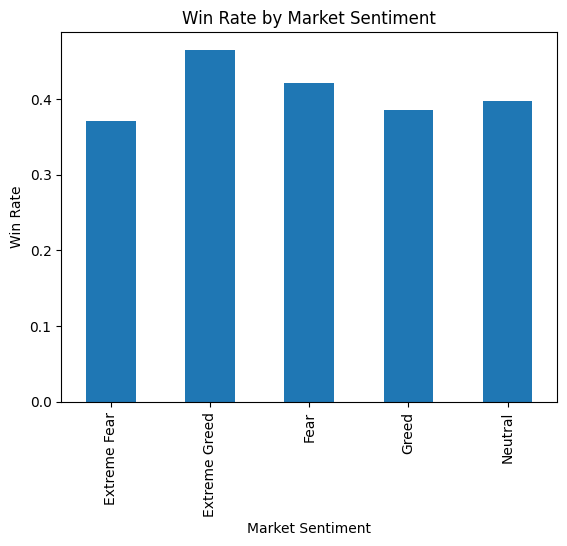

In [ ]:
win_rate.plot(kind='bar')

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")

plt.show()

The win rate varies across market sentiment conditions. It is highest during Extreme Greed, indicating that traders are most successful in highly bullish market conditions. The win rate is lower during Extreme Fear, suggesting reduced profitability during highly negative sentiment. Fear and Neutral conditions show moderate performance, indicating mixed trading outcomes.

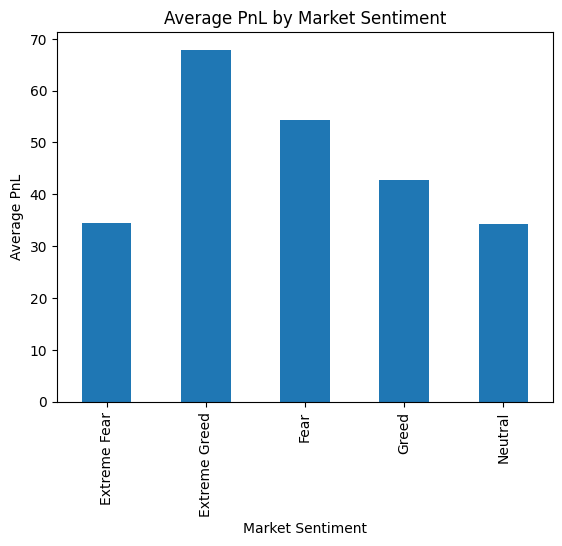

In [ ]:
avg_pnl = merged.groupby("classification")["Closed PnL"].mean()

avg_pnl.plot(kind='bar')

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.show()

The average PnL is significantly higher during Extreme Greed, showing that traders achieve maximum profitability in strongly bullish markets. In contrast, Extreme Fear and Neutral conditions show relatively lower average PnL. This indicates that strong positive sentiment leads to better profit opportunities, while uncertain or negative sentiment reduces profitability.

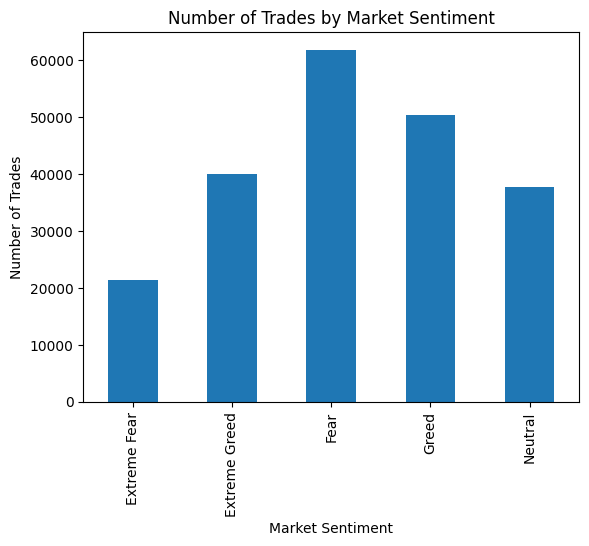

In [ ]:
trade_count = merged.groupby("classification").size()

trade_count.plot(kind='bar')

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

Trading activity is highest during Fear conditions, followed by Greed and Extreme Greed. The lowest number of trades occurs during Extreme Fear. This suggests that traders are more active during uncertain or volatile conditions, possibly trying to capitalize on rapid price movements.

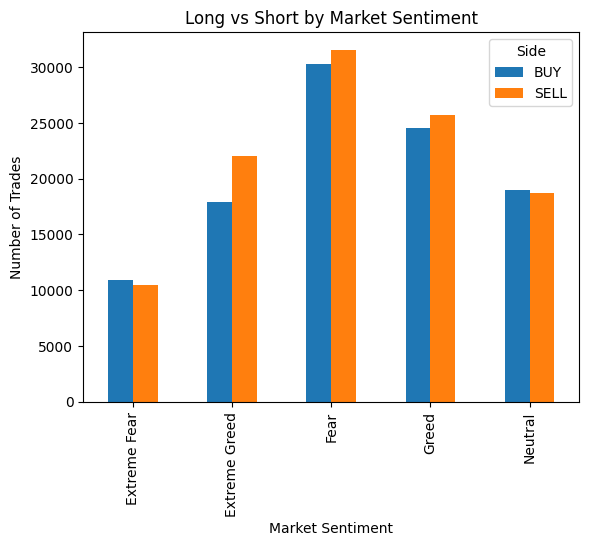

In [ ]:
side_sentiment = merged.groupby(["classification", "Side"]).size().unstack()

side_sentiment.plot(kind='bar')

plt.title("Long vs Short by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

Traders exhibit a slight preference for SELL positions during Fear and Greed conditions, indicating cautious or bearish behavior. During Extreme Fear, BUY and SELL activity is nearly balanced, showing uncertainty in decision-making. In Neutral conditions, both BUY and SELL trades are almost equal, indicating no strong directional bias.

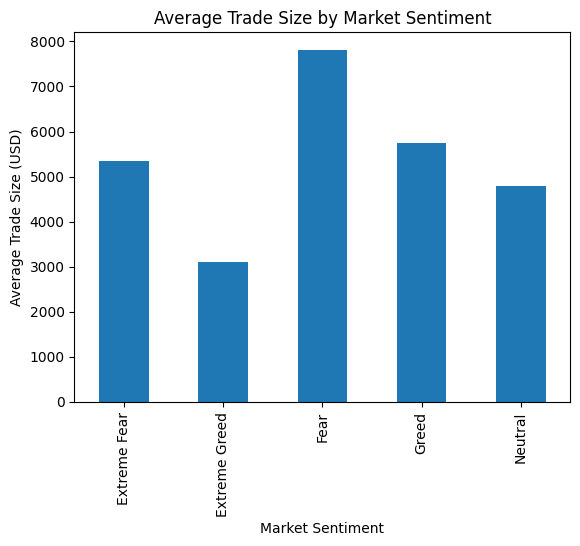

In [ ]:
avg_trade_size = merged.groupby("classification")["Size USD"].mean()

avg_trade_size.plot(kind='bar')

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.show()

The average trade size is highest during Fear, indicating that traders take larger positions during uncertain market conditions. Surprisingly, Extreme Greed shows the lowest trade size, suggesting that while traders are more profitable, they trade with smaller positions. This indicates a shift in risk management strategies across sentiment phases.

## Part B — Analysis

1. Does performance differ between Fear vs Greed?

Yes, trader performance varies significantly across market sentiment conditions. Based on the analysis, both win rate and average PnL are highest during Extreme Greed, indicating that traders achieve better profitability in strongly bullish markets. In contrast, Extreme Fear shows the lowest win rate and lower PnL, suggesting that traders struggle to generate profits during highly negative sentiment. Fear and Neutral conditions show moderate performance, indicating mixed outcomes.

2. Do traders change behavior based on sentiment?

Yes, trader behavior changes noticeably with market sentiment:

Trade Frequency: Trading activity is highest during Fear, indicating increased participation during uncertain or volatile conditions.
Long/Short Bias: Traders show a slight preference for SELL positions during Fear and Greed, suggesting cautious or bearish tendencies.
Position Size: The average trade size is highest during Fear, indicating larger positions in uncertain markets, while it is lowest during Extreme Greed, suggesting more controlled risk-taking despite higher profitability.

This demonstrates that traders adjust their activity, direction, and risk exposure based on market sentiment.

Segment 1: Frequent vs Infrequent Traders

Traders were segmented based on trading activity. Frequent traders execute a higher number of trades and tend to achieve better average performance compared to infrequent traders. This suggests that active participation may improve decision-making and market timing.

Segment 2: Winners vs Losers

Traders were also segmented based on profitability. Winning traders consistently generate positive PnL, while losing traders incur losses. This highlights differences in strategy effectiveness and risk management among traders.

3 Key Insights

Trader performance is strongest during Extreme Greed, with the highest win rate and average PnL.

Traders are most active during Fear conditions, indicating that volatility drives higher trading participation.

Traders take larger positions during Fear but achieve better profitability during Extreme Greed with relatively smaller trade sizes.

## Part C — Actionable Output

Strategy 1: Sentiment-Based Trade Selection

During Extreme Greed periods, traders achieve the highest win rate and profitability. Therefore, traders should prioritize trading during bullish sentiment phases and avoid excessive trading during Fear conditions, where performance is weaker. This alignment with favorable market sentiment can improve overall profitability.

Strategy 2: Dynamic Position Sizing

The analysis shows that traders take larger positions during Fear but achieve better results during Extreme Greed with smaller positions. Therefore, traders should reduce position size during Fear to manage risk and increase exposure moderately during Greed periods, where market conditions are more favorable.

## Bonus

Bonus: Predictive Model Idea

A simple predictive model can be built using features such as market sentiment, trade size, trade frequency, and trade direction to predict next-day trader profitability (profit/loss classification). This can help traders anticipate favorable conditions and adjust strategies accordingly.

Bonus: Clustering Idea

Traders can be clustered into different groups such as high-frequency vs low-frequency and risk-taking vs conservative traders. This helps identify which trader types perform better under different market conditions.

Bonus: Dashboard Idea

A lightweight dashboard can be built using Streamlit to visualize key metrics such as PnL, win rate, and trading behavior across different market sentiment conditions. This would allow users to interactively explore patterns and gain insights for better decision-making.